In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

This part loads the tools we need to work with data.

Pandas helps us read and organize data in tables.

NumPy helps with numerical calculations.

Matplotlib and Seaborn are used to create graphs and visualizations.

Think of these libraries as toolkits—each one helps with a different job, like measuring, organizing, or drawing charts.

In [2]:
#Dataset: https://www.kaggle.com/datasets/himanshunakrani/iris-dataset
iris = pd.read_csv('iris.csv')

This line loads the Iris dataset from a CSV file and stores it in a table called iris.

A CSV file is similar to an Excel spreadsheet. Each row represents a flower, and each column represents a measurement like sepal length or petal width.

In [15]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


This command shows the first few rows of the dataset.

It helps us quickly check if the data loaded correctly and understand what kind of information is inside the dataset.

In [4]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


This shows basic details about the dataset, such as:

How many rows and columns there are

The names of the columns

The type of data stored in each column

It is useful for checking if there are missing values and confirming that the data is in the correct format.

In [5]:
iris.replace('setosa', 0, inplace=True)
iris.replace('versicolor', 1, inplace=True)
iris.replace('virginica', 2, inplace=True)


C:\Users\okoye\AppData\Local\Temp\ipykernel_30248\1612907344.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  iris.replace('virginica', 2, inplace=True)


Computers work better with numbers than words.
This code replaces flower names with numbers:

Setosa → 0

Versicolor → 1

Virginica → 2

This makes the data suitable for machine learning models later in the assignment.

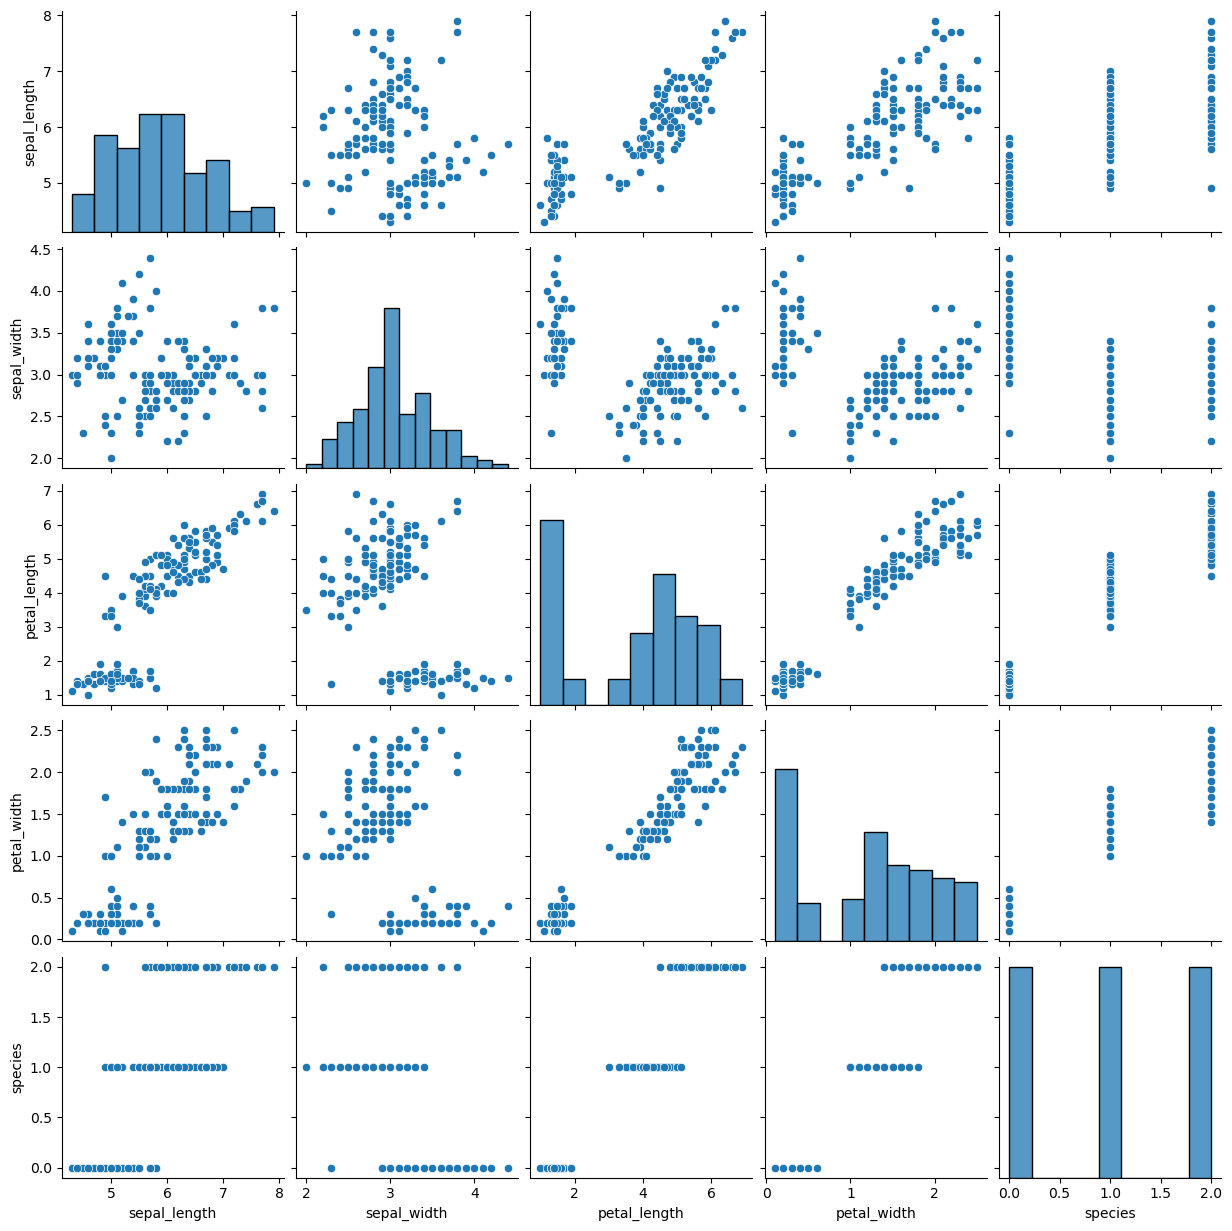

In [6]:
sns.pairplot(iris)

This creates multiple graphs that compare every measurement with every other measurement.

It helps us visually see patterns, trends, and relationships between features like petal length and sepal width across different species.

Text(0.5, 1.0, 'Average Sepal Length by Iris Species')

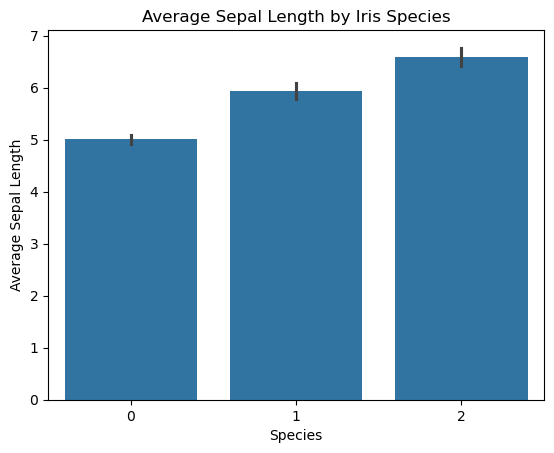

In [7]:
sns.barplot(data=iris, x='species', y='sepal_length')
plt.xlabel('Species')
plt.ylabel('Average Sepal Length')
plt.title('Average Sepal Length by Iris Species')

This graph shows the average sepal length for each species of iris flower.

Bar charts make it easy to compare values and see which species tends to have longer or shorter sepals.

This bar chart shows the average sepal length for each Iris species. It highlights that virginica has the largest average sepal length, followed by versicolor, while setosa has the smallest.

Text(0.5, 1.0, 'Quartiles of Sepal Width by Iris Species')

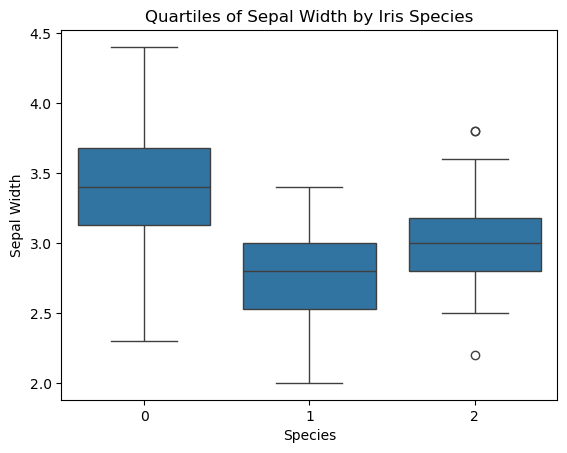

In [8]:
sns.boxplot(data=iris, x='species', y='sepal_width')
plt.ylabel('Sepal Width')
plt.xlabel('Species')
plt.title('Quartiles of Sepal Width by Iris Species')

This box plot shows how sepal width is distributed for each species.

It helps us see:

The median value

The spread of the data

Any possible outliers

Box plots are useful for understanding variation, not just averages.

Text(0.5, 1.0, 'Quartiles of Petal Length by Iris Species')

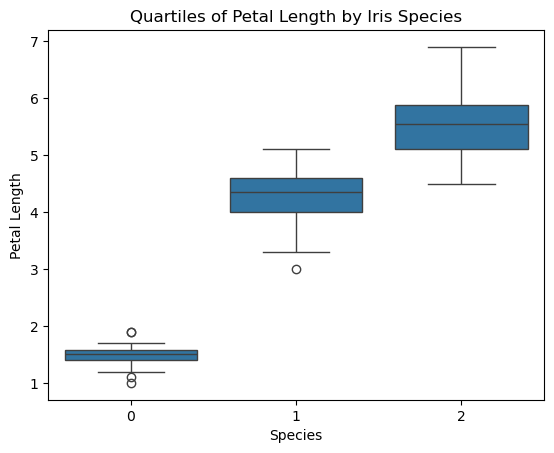

In [9]:
sns.boxplot(data=iris, x='species', y='petal_length')
plt.xlabel('Species')
plt.ylabel('Petal Length')
plt.title('Quartiles of Petal Length by Iris Species')

This box plot shows the distribution of petal length for each Iris species, including the median, quartiles, and outliers. It highlights clear differences between species, with setosa having much smaller petal lengths compared to versicolor and virginica.

In [10]:
X, y = iris.drop('species', axis=1), iris['species'].values

Here, the data is split into two parts:

X: All the measurements (sepal and petal sizes)

y: The species label (what kind of flower it is)

This separation is necessary so the model can learn from the measurements and predict the species.

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=87)

This divides the data into two groups:

Training data (70%): Used to teach the model

Testing data (30%): Used to check how accurate the model is

The random_state ensures the split is the same every time the code is run.

In [12]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(max_iter=500)
logmodel.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


This creates a Logistic Regression model, which is commonly used for classification problems.

The model is trained using the training data so it can learn how flower measurements relate to flower species.

In [13]:
predictions = logmodel.predict(X_test)
logmodel.score(X_test, y_test)

0.9777777777777777

The model predicts the species of flowers in the test data.

The score shows how accurate the model is by comparing the predictions with the actual species values.

In [14]:
myTest = {
        'sepal_length':[6],
        'sepal_width':[2.6],
        'petal_length':[1.2],
        'petal_width':[1.2]
       }
df = pd.DataFrame(myTest)
print(logmodel.predict(df))

[0]


This section tests the model with a new flower that was not in the original dataset.

The measurements are entered manually, and the model predicts which species the flower most likely belongs to.

This shows how machine learning can be used to make real-world predictions.